In [17]:
import pandas as pd
import os

os.chdir(os.path.expanduser('~/methane-justice'))

# Load without any header specification
df_raw = pd.read_excel('data/edgar/CH4_total/v60_CH4_1970_2018.xls', header=None)

print("Raw shape:", df_raw.shape)
print("\nFirst 10 rows, first 8 columns:")
print(df_raw.iloc[:10, :8])

# Find the row with 'IPCC_annex' — that's the real header
for idx in range(len(df_raw)):
    if df_raw.iloc[idx, 0] == 'IPCC_annex':
        print(f"\nHeader row found at index: {idx}")
        print(f"Header: {df_raw.iloc[idx, :10].values}")
        break

Raw shape: (4629, 56)

First 10 rows, first 8 columns:
                                                   0  \
0                                           Content:   
1                                          Compound:   
2                                        Start year:   
3                                          End year:   
4                                              Unit:   
5  Reference: European Commission, Joint Research...   
6  Users of the data are obliged to acknowledge t...   
7                                     Data download:   
8                                                NaN   
9                                         IPCC_annex   

                                               1                2     3  \
0  Emissions by country and main source category              NaN   NaN   
1                                            CH4              NaN   NaN   
2                                           1970              NaN   NaN   
3                           

In [18]:


os.chdir(os.path.expanduser('~/methane-justice'))

# Load with row 9 as header
df = pd.read_excel('data/edgar/CH4_total/v60_CH4_1970_2018.xls', 
                    header=9)

print("Columns:")
print(df.columns.tolist()[:15])  # Show first 15

print("\nShape:", df.shape)
print("\nFirst 3 rows:")
print(df[['Name', 'Y_2018']].head(3))

# Now aggregate by country
emissions_2018 = df.groupby('Name')['Y_2018'].sum().reset_index()
emissions_2018.columns = ['Country', 'CH4_emissions_Gg_2018']
emissions_2018 = emissions_2018.sort_values('CH4_emissions_Gg_2018', ascending=False)

print(f"\nTOP 20 METHANE EMITTERS (2018):")
print(emissions_2018.head(20).to_string())

# Save
emissions_2018.to_csv('data/edgar-ch4-2018-by-country.csv', index=False)
print("\n✓ Saved: data/edgar-ch4-2018-by-country.csv")

Columns:
['IPCC_annex', 'C_group_IM24_sh', 'Country_code_A3', 'Name', 'ipcc_code_2006_for_standard_report', 'ipcc_code_2006_for_standard_report_name', 'fossil_bio', 'Y_1970', 'Y_1971', 'Y_1972', 'Y_1973', 'Y_1974', 'Y_1975', 'Y_1976', 'Y_1977']

Shape: (4619, 56)

First 3 rows:
     Name    Y_2018
0  Canada  2.351546
1  Canada  1.923461
2  Canada  5.242324

TOP 20 METHANE EMITTERS (2018):
                       Country  CH4_emissions_Gg_2018
40                       China           65936.162393
94                       India           30737.899690
218              United States           25522.696700
27                      Brazil           22771.536538
171         Russian Federation           16387.711549
95                   Indonesia           14705.074391
157                   Pakistan            8660.027603
151                    Nigeria            8658.514702
98   Iran, Islamic Republic of            8549.837961
134                     Mexico            6616.199702
99            

In [19]:


os.chdir(os.path.expanduser('~/methane-justice'))

# List files in ND-GAIN folders
nd_gain_path = Path('data/nd-gain-vulnerability')

for folder in nd_gain_path.iterdir():
    if folder.is_dir():
        files = list(folder.glob('*.csv'))
        print(f"\n{folder.name}/ ({len(files)} files):")
        for f in sorted(files)[:5]:  # Show first 5
            print(f"  • {f.name}")


trends/ (3 files):
  • gain.csv
  • readiness.csv
  • vulnerability.csv

gain/ (2 files):
  • gain.csv
  • gain_delta.csv

vulnerability/ (11 files):
  • capacity.csv
  • ecosystems.csv
  • exposure.csv
  • food.csv
  • habitat.csv

indicators/ (0 files):

readiness/ (5 files):
  • economic.csv
  • governance.csv
  • readiness.csv
  • readiness_delta.csv
  • social.csv


In [20]:


os.chdir(os.path.expanduser('~/methane-justice'))

# Load the main GAIN index (vulnerability + readiness combined)
gain = pd.read_csv('data/nd-gain-vulnerability/gain/gain.csv')

print("GAIN columns:")
print(gain.columns.tolist())

print("\nShape:", gain.shape)
print("\nFirst 5 rows:")
print(gain.head())

print("\nCountry column name:")
print(gain.columns[0])

GAIN columns:
['ISO3', 'Name', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

Shape: (192, 31)

First 5 rows:
  ISO3         Name       1995       1996       1997       1998       1999  \
0  AFG  Afghanistan  34.859009  34.850554  34.927518  35.095338  35.086928   
1  ALB      Albania  44.057068  44.039788  43.973939  43.720561  43.425650   
2  DZA      Algeria  45.097460  45.199544  45.088019  45.081642  45.410493   
3  AND      Andorra        NaN        NaN        NaN        NaN        NaN   
4  AGO       Angola  34.827437  34.809935  34.747298  34.684426  34.714635   

        2000       2001       2002  ...       2014       2015       2016  \
0  35.082468  35.485125  35.891927  ...  32.918922  33.055386  33.355206   
1  43.559159  43.794627  44.222181  ...  49.729500  50.204170  49.887834   
2  45.6

In [21]:


os.chdir(os.path.expanduser('~/methane-justice'))

# Load emissions
emissions = pd.read_csv('data/edgar-ch4-2018-by-country.csv')

# Load GAIN vulnerability
gain = pd.read_csv('data/nd-gain-vulnerability/gain/gain.csv')

# Get 2018 GAIN index (vulnerability score)
gain_2018 = gain[['Name', '2018']].copy()
gain_2018.columns = ['Country', 'GAIN_Vulnerability_2018']

print("GAIN data shape:", gain_2018.shape)
print("Sample GAIN data:")
print(gain_2018.head())

# Merge on country name
merged = emissions.merge(gain_2018, on='Country', how='left')

print(f"\nMerged shape: {merged.shape}")
print(f"Countries matched: {merged['GAIN_Vulnerability_2018'].notna().sum()}")

# Sort by emissions
merged = merged.sort_values('CH4_emissions_Gg_2018', ascending=False)

print("\n" + "="*80)
print("TOP 20: EMISSIONS vs VULNERABILITY (GAIN Index)")
print("="*80)
print(merged[['Country', 'CH4_emissions_Gg_2018', 'GAIN_Vulnerability_2018']].head(20).to_string())

# Save merged data
merged.to_csv('data/emissions-gain-vulnerability-merged.csv', index=False)
print("\n✓ Saved: data/emissions-gain-vulnerability-merged.csv")

# Show the MISMATCH (climate injustice)
print("\n" + "="*80)
print("FREE RIDERS: High Emissions, Low Vulnerability (>50% emitters, <40 vulnerability)")
print("="*80)
free_riders = merged[(merged['CH4_emissions_Gg_2018'] > merged['CH4_emissions_Gg_2018'].quantile(0.5)) & 
                     (merged['GAIN_Vulnerability_2018'] < 40)]
print(free_riders[['Country', 'CH4_emissions_Gg_2018', 'GAIN_Vulnerability_2018']].to_string())

print("\n" + "="*80)
print("MOST VULNERABLE, LOW EMISSIONS (<2000 Gg, >60 vulnerability)")
print("="*80)
vulnerable = merged[(merged['CH4_emissions_Gg_2018'] < 2000) & 
                    (merged['GAIN_Vulnerability_2018'] > 60)]
print(vulnerable[['Country', 'CH4_emissions_Gg_2018', 'GAIN_Vulnerability_2018']].to_string())

GAIN data shape: (192, 2)
Sample GAIN data:
       Country  GAIN_Vulnerability_2018
0  Afghanistan                32.473637
1      Albania                50.329419
2      Algeria                47.155766
3      Andorra                      NaN
4       Angola                37.105784

Merged shape: (232, 3)
Countries matched: 179

TOP 20: EMISSIONS vs VULNERABILITY (GAIN Index)
                      Country  CH4_emissions_Gg_2018  GAIN_Vulnerability_2018
0                       China           65936.162393                53.862640
1                       India           30737.899690                42.585662
2               United States           25522.696700                67.808832
3                      Brazil           22771.536538                48.720489
4          Russian Federation           16387.711549                60.498967
5                   Indonesia           14705.074391                45.897778
6                    Pakistan            8660.027603                38.136

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster
import os

os.chdir(os.path.expanduser('~/methane-justice'))

merged = pd.read_csv('data/emissions-gain-vulnerability-merged.csv')

# ===== SCATTER PLOT: THE SMOKING GUN =====
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all countries
scatter = ax.scatter(merged['CH4_emissions_Gg_2018'], 
                     merged['GAIN_Vulnerability_2018'],
                     s=200, alpha=0.6, c='steelblue', edgecolors='navy', linewidth=1)

# Highlight top emitters (red)
top_emitters = merged.nlargest(10, 'CH4_emissions_Gg_2018')
ax.scatter(top_emitters['CH4_emissions_Gg_2018'], 
           top_emitters['GAIN_Vulnerability_2018'],
           s=300, c='red', marker='o', edgecolors='darkred', linewidth=2, label='Top 10 Emitters', zorder=5)

# Highlight most vulnerable (green)
most_vulnerable = merged.nlargest(10, 'GAIN_Vulnerability_2018')
ax.scatter(most_vulnerable['CH4_emissions_Gg_2018'], 
           most_vulnerable['GAIN_Vulnerability_2018'],
           s=300, c='green', marker='^', edgecolors='darkgreen', linewidth=2, label='Most Vulnerable', zorder=5)

# Add country labels for extremes
for idx, row in merged.iterrows():
    if row['CH4_emissions_Gg_2018'] > 15000 or row['GAIN_Vulnerability_2018'] > 70:
        ax.annotate(row['Country'], 
                   (row['CH4_emissions_Gg_2018'], row['GAIN_Vulnerability_2018']),
                   fontsize=9, alpha=0.7, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Methane Emissions (Gg CH4/year)', fontsize=12, fontweight='bold')
ax.set_ylabel('Climate Vulnerability Index (0-100, higher=more vulnerable)', fontsize=12, fontweight='bold')
ax.set_title('Climate Justice: Who Emits vs Who Suffers\nMethane Emissions vs Climate Vulnerability', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=11, loc='upper left')

# Add quadrant lines
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axvline(x=merged['CH4_emissions_Gg_2018'].median(), color='gray', linestyle='--', alpha=0.3, linewidth=1)

# Quadrant labels
ax.text(0.98, 0.95, 'HIGH VULNERABILITY\nLOW EMISSIONS\n(Victims)', 
        transform=ax.transAxes, fontsize=10, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax.text(0.98, 0.05, 'LOW VULNERABILITY\nHIGH EMISSIONS\n(Free Riders)', 
        transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

plt.tight_layout()
plt.savefig('outputs/emissions-vs-vulnerability-scatter.png', dpi=300, bbox_inches='tight')
print("✓ Saved: outputs/emissions-vs-vulnerability-scatter.png")
plt.show()

# ===== CORRELATION COEFFICIENT =====
correlation = merged[['CH4_emissions_Gg_2018', 'GAIN_Vulnerability_2018']].corr().iloc[0, 1]
print(f"\nCorrelation (Emissions vs Vulnerability): {correlation:.3f}")
if correlation < 0:
    print("⚠️  NEGATIVE correlation = high emitters are LESS vulnerable (climate injustice)")
elif correlation > 0:
    print("✓ Positive correlation = emitters also vulnerable")
else:
    print("No correlation = emissions unrelated to vulnerability")

✓ Saved: outputs/emissions-vs-vulnerability-scatter.png


<Figure size 1400x1000 with 1 Axes>


Correlation (Emissions vs Vulnerability): 0.055
✓ Positive correlation = emitters also vulnerable


EMISSIONS DISTRIBUTION:
count      232.000000
mean      1617.826745
std       5517.521493
min          0.000000
25%          7.485942
50%        314.225085
75%       1007.746783
max      65936.162393
Name: CH4_emissions_Gg_2018, dtype: float64

Top emitter (China): 65936 Gg
Median: 314 Gg
Bottom 50%: < 314 Gg

VULNERABILITY DISTRIBUTION:
count    179.000000
mean      49.450136
std       10.756113
min       26.780969
25%       40.897074
50%       48.720489
75%       56.459219
max       76.163816
Name: GAIN_Vulnerability_2018, dtype: float64

✓ Saved: outputs/emissions-vs-vulnerability-comparison.png


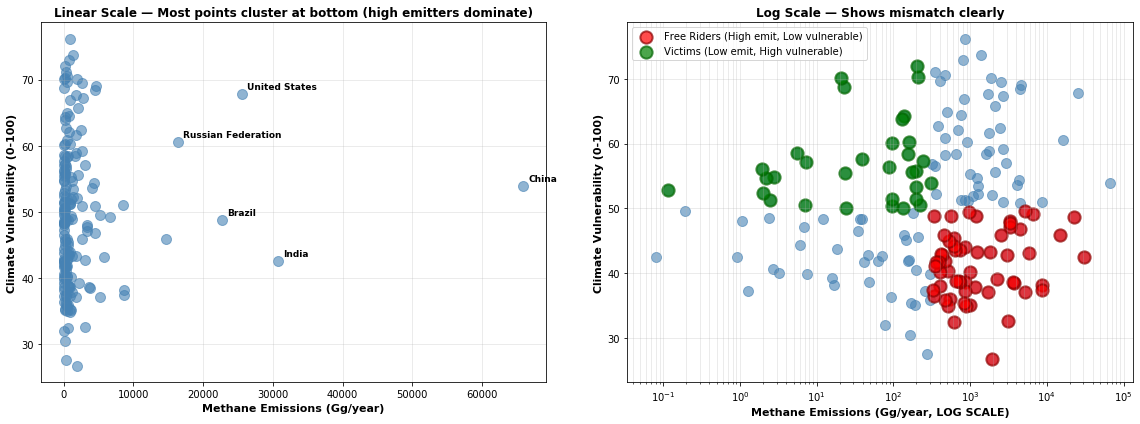


FREE RIDERS (High Emissions, Low Vulnerability):
                              Country  CH4_emissions_Gg_2018  GAIN_Vulnerability_2018
1                               India           30737.899690                42.585662
3                              Brazil           22771.536538                48.720489
5                           Indonesia           14705.074391                45.897778
6                            Pakistan            8660.027603                38.136541
7                             Nigeria            8658.514702                37.494545
9                              Mexico            6616.199702                49.182984
10                               Iraq            5800.445646                43.173834
11                         Bangladesh            5191.586588                37.146947
12                          Argentina            5189.054255                49.548347
15                           Viet Nam            4490.917760                46.888124
19  

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir(os.path.expanduser('~/methane-justice'))

merged = pd.read_csv('data/emissions-gain-vulnerability-merged.csv')

# Check distribution
print("EMISSIONS DISTRIBUTION:")
print(merged['CH4_emissions_Gg_2018'].describe())
print(f"\nTop emitter (China): {merged.iloc[0]['CH4_emissions_Gg_2018']:.0f} Gg")
print(f"Median: {merged['CH4_emissions_Gg_2018'].median():.0f} Gg")
print(f"Bottom 50%: < {merged['CH4_emissions_Gg_2018'].quantile(0.5):.0f} Gg")

print("\n" + "="*80)
print("VULNERABILITY DISTRIBUTION:")
print(merged['GAIN_Vulnerability_2018'].describe())

# Create BETTER scatter plot with LOG scale
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Linear scale (shows the extreme inequality)
ax1 = axes[0]
scatter1 = ax1.scatter(merged['CH4_emissions_Gg_2018'], 
                       merged['GAIN_Vulnerability_2018'],
                       s=100, alpha=0.6, c='steelblue')
ax1.set_xlabel('Methane Emissions (Gg/year)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Climate Vulnerability (0-100)', fontsize=11, fontweight='bold')
ax1.set_title('Linear Scale — Most points cluster at bottom (high emitters dominate)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

# Label top emitters
for idx, row in merged.nlargest(5, 'CH4_emissions_Gg_2018').iterrows():
    ax1.annotate(row['Country'], (row['CH4_emissions_Gg_2018'], row['GAIN_Vulnerability_2018']),
                fontsize=9, xytext=(5, 5), textcoords='offset points', fontweight='bold')

# RIGHT: Log scale (shows pattern more clearly)
ax2 = axes[1]
scatter2 = ax2.scatter(merged['CH4_emissions_Gg_2018'], 
                       merged['GAIN_Vulnerability_2018'],
                       s=100, alpha=0.6, c='steelblue')
ax2.set_xscale('log')
ax2.set_xlabel('Methane Emissions (Gg/year, LOG SCALE)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Climate Vulnerability (0-100)', fontsize=11, fontweight='bold')
ax2.set_title('Log Scale — Shows mismatch clearly', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, which='both')

# Color-code by quadrant in log plot
high_emit_low_vuln = merged[(merged['CH4_emissions_Gg_2018'] > merged['CH4_emissions_Gg_2018'].median()) & 
                            (merged['GAIN_Vulnerability_2018'] < 50)]
low_emit_high_vuln = merged[(merged['CH4_emissions_Gg_2018'] < merged['CH4_emissions_Gg_2018'].median()) & 
                            (merged['GAIN_Vulnerability_2018'] > 50)]

ax2.scatter(high_emit_low_vuln['CH4_emissions_Gg_2018'], 
           high_emit_low_vuln['GAIN_Vulnerability_2018'],
           s=150, c='red', alpha=0.7, edgecolors='darkred', linewidth=2, label='Free Riders (High emit, Low vulnerable)')
ax2.scatter(low_emit_high_vuln['CH4_emissions_Gg_2018'], 
           low_emit_high_vuln['GAIN_Vulnerability_2018'],
           s=150, c='green', alpha=0.7, edgecolors='darkgreen', linewidth=2, label='Victims (Low emit, High vulnerable)')

ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/emissions-vs-vulnerability-comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: outputs/emissions-vs-vulnerability-comparison.png")
plt.show()

# Show the quadrants
print("\n" + "="*80)
print("FREE RIDERS (High Emissions, Low Vulnerability):")
print(high_emit_low_vuln[['Country', 'CH4_emissions_Gg_2018', 'GAIN_Vulnerability_2018']].sort_values('CH4_emissions_Gg_2018', ascending=False).to_string())

print("\n" + "="*80)
print("CLIMATE VICTIMS (Low Emissions, High Vulnerability):")
print(low_emit_high_vuln[['Country', 'CH4_emissions_Gg_2018', 'GAIN_Vulnerability_2018']].sort_values('GAIN_Vulnerability_2018', ascending=False).to_string())

In [29]:
exec(open('/home/vittoria/methane-justice/notebooks/create-climate-justice-map.py').read())

✓ Saved: outputs/climate-justice-interactive-map.html

Open this file in your browser to explore the map interactively!
